In [1]:
#Load Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Load the Datasets

trades = pd.read_csv("/content/historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index.csv")


In [4]:
#Check Data

trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
#Basic Data Understanding

print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [7]:
# Data Cleaning
#checking missing values

trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [8]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [9]:
#Converting Dates to Datetime Format

trades['time'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['date'] = trades['time'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['date'] = sentiment['date'].dt.date

In [10]:
#Remove rows with missing important values

trades = trades.dropna(subset=['Size Tokens', 'Closed PnL','date'])
sentiment = sentiment.dropna(subset=['date','classification'])

In [11]:
#Merge both datasets

merged = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

In [12]:
#Check result

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed


In [13]:
#Save merged dataset

merged.to_csv('merged_dataset.csv', index=False)

In [14]:
# Profitability
# Profit/Loss VS Market Sentiment

merged.groupby('classification')['Closed PnL'].mean()


,Closed PnL
classification,
Extreme Fear,21.455587
Extreme Greed,456.166481
Fear,287.379964
Greed,73.075440
Neutral,37.320966


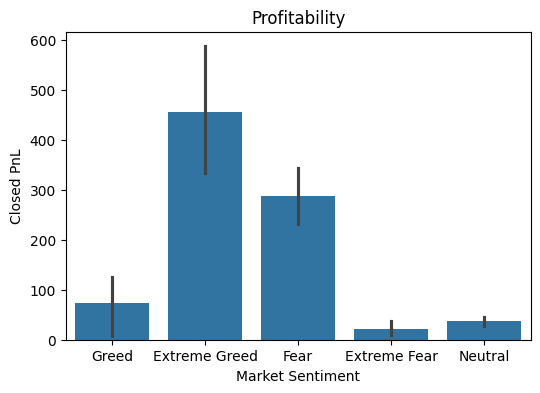

In [15]:
# Plot

plt.figure(figsize=(6, 4))
sns.barplot(x='classification', y='Closed PnL', data=merged)
plt.title('Profitability')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')
plt.savefig('PnL_vs_Sentiment.png')
plt.show()

In [16]:
# Risk Proximity(Volume)
# Trade size VS Sentiment

merged.groupby('classification')['Size Tokens'].mean()


,Size Tokens
classification,
Extreme Fear,351.267726
Extreme Greed,35284.105363
Fear,7388.951426
Greed,33678.776870
Neutral,41085.271315


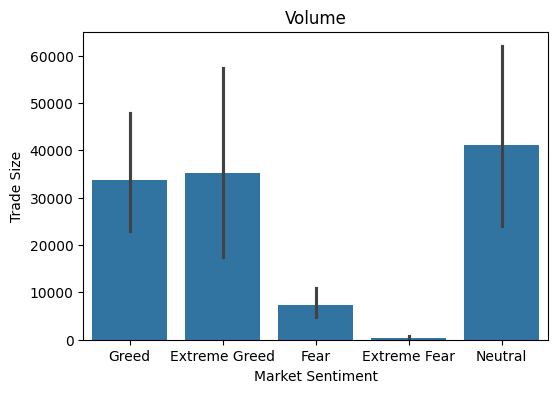

In [17]:
# Plot

plt.figure(figsize=(6, 4))
sns.barplot(x='classification', y='Size Tokens', data=merged)
plt.title('Volume')
plt.xlabel('Market Sentiment')
plt.ylabel('Trade Size')
plt.savefig('Volume_vs_Sentiment.png')
plt.show()

In [18]:
# Volatility(Risk Behaviour)
# Profit/Loss VS Market Sentiment

merged.groupby('classification')['Closed PnL'].std()

,Closed PnL
classification,
Extreme Fear,98.657455
Extreme Greed,3003.406812
Fear,2109.127449
Greed,2067.727312
Neutral,155.237827


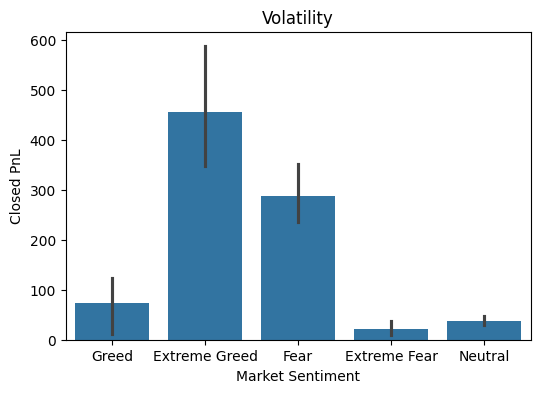

In [20]:
#Plot

plt.figure(figsize=(6, 4))
sns.barplot(x='classification', y='Closed PnL', data=merged)
plt.title('Volatility')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')
plt.savefig('Volatility_vs_Sentiment.png')
plt.show()

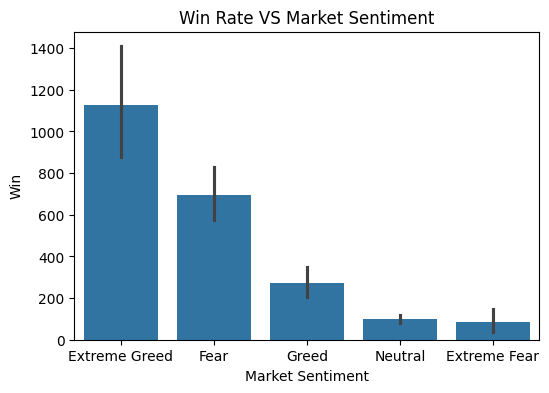

In [21]:
#Win Rate

win = merged[merged['Closed PnL'] > 0]
win.groupby('classification')['Closed PnL'].mean()
plt.figure(figsize=(6, 4))
sns.barplot(x='classification', y='Closed PnL', data=win)
plt.title('Win Rate VS Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win')
plt.savefig('Win_Rate_vs_Sentiment.png')
plt.show()

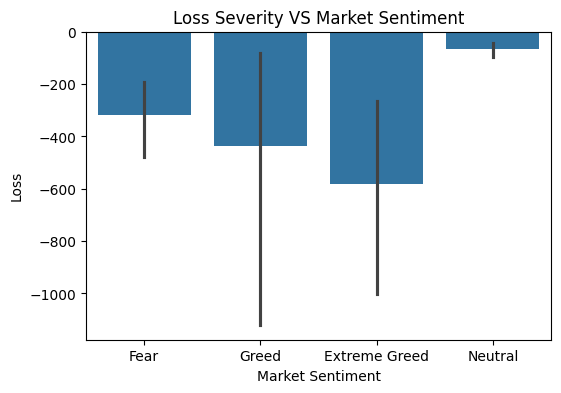

In [22]:
#Loss Severity

loss = merged[merged['Closed PnL'] < 0]
loss.groupby('classification')['Closed PnL'].mean()
plt.figure(figsize=(6, 4))
sns.barplot(x='classification', y='Closed PnL', data=loss)
plt.title('Loss Severity VS Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Loss')
plt.savefig('Loss_Severity_vs_Sentiment.png')
plt.show()